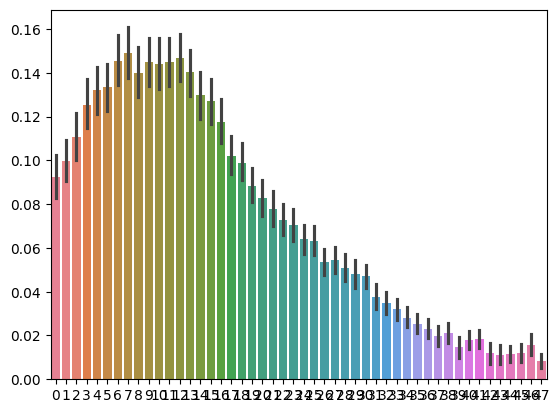

In [ ]:
import pandas as pd
import ast
import seaborn as sns
import matplotlib.pyplot as plt

result_names = [
    "results_2025-08-28_13-41-37_gpt2-xl"
]

for filename in result_names:
    df = pd.read_csv(f"{filename}.csv")

    df['clean'] = df['clean'].apply(ast.literal_eval)

    df['corrupted'] = df['corrupted'].apply(ast.literal_eval)
    df['restored'] = df['restored'].apply(ast.literal_eval)
    df_expanded = df['restored'].apply(pd.Series)

    df_final = pd.concat([df.drop('restored', axis=1), df_expanded], axis=1)
    df_final["clean_token"] = df_final["clean"].apply(lambda x: x[0])
    df_final["clean"] = df_final["clean"].apply(lambda x: x[1])

    df_ff = df_final
    df_ff["corrupted"] = df_ff["corrupted"].apply(lambda x: x[1])
    
    for i in range(48):
        df_ff[i] = df_ff[i].apply(lambda x: x[1])
        df_ff[i] = df_ff[i] - df_ff["corrupted"]

    df_preproc = df_ff
    df_preproc = df_preproc.drop('clean', axis=1)
    df_preproc = df_preproc.drop('corrupted', axis=1)
    df_p_g = df_preproc.groupby(["run_number"]).max(["restored_token"]).drop("restored_token", axis=1)

    sns.barplot(data=df_p_g)
    plt.show()
